In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from scipy.special import erf


In [3]:
def inch_to_mm(x):
    return(x * 25.4)

In [4]:
# === Load first sheet ===
df1 = pd.read_excel(
    'KnifeEdge_OPA.xlsx',
    skiprows=1,
    sheet_name=0  # First sheet
)

# Drop any fully empty rows
df1 = df1.dropna(how='all')

# Extract data blocks from first sheet
block0 = df1.iloc[:, 0:3].dropna()
pos_06_5 = np.array([block0.iloc[:, 0].values, block0.iloc[:, 1].values, block0.iloc[:, 2].values])

block1 = df1.iloc[:, 4:7].dropna()
pos_20_5 = np.array([block1.iloc[:, 0].values, block1.iloc[:, 1].values, block1.iloc[:, 2].values])

blockm1 = df1.iloc[:, 8:11].dropna()
pos_02_5 = np.array([blockm1.iloc[:, 0].values, blockm1.iloc[:, 1].values, blockm1.iloc[:, 2].values])

print("Sheet 1:")
print("pos06.5 shape:", pos_06_5.shape)
print("pos20.5 shape:", pos_20_5.shape)
print("pos02.5 shape:", pos_02_5.shape)

Sheet 1:
pos06.5 shape: (3, 50)
pos20.5 shape: (3, 57)
pos02.5 shape: (3, 53)


# Beam Radius

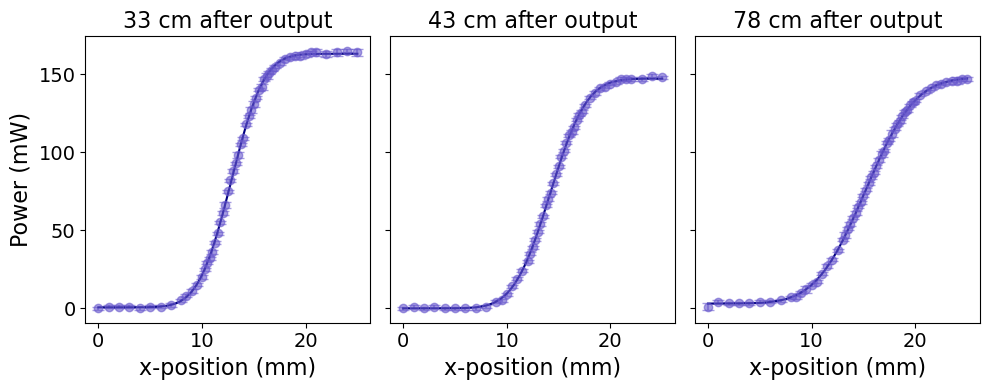


Fitted Parameters (a, b, wZ, x0):

Front | 33 cm after output -> a = -162.659, b = 163.173, wZ = 4.979, x0 = 12.833
Front | 43 cm after output -> a = -147.376, b = 147.228, wZ = 5.522, x0 = 14.187
Front | 78 cm after output -> a = -144.969, b = 147.881, wZ = 7.509, x0 = 15.200


In [16]:
# --- Define the fit function ---
def fit_func(x, a, b, wZ, x0):
    return (a / 2) * (1 - erf(np.sqrt(2) * (x - x0) / wZ)) + b

# --- Helper function to do fitting and plotting ---
def fit_and_plot(ax, x, y, yerr, title, show_ylabel=False):
    p0 = [max(y) - min(y), min(y), 1.0, np.mean(x)]
    bounds = ([-np.inf, -np.inf, 1e-6, -np.inf], [np.inf, np.inf, np.inf, np.inf])
    popt, pcov = curve_fit(fit_func, x, y, sigma=yerr, p0=p0, bounds=bounds, absolute_sigma=True)

    x_fit = np.linspace(min(x), max(x), 300)
    y_fit = fit_func(x_fit, *popt)

    ax.errorbar(x, y, yerr=yerr, fmt='o', capsize=4, color='slateblue', alpha=0.6,  label='Data')
    ax.plot(x_fit, y_fit, '-', color='navy', label='Fit')

    ax.set_title(title, fontsize=16)
    ax.tick_params(axis='x', labelsize=14)
    ax.tick_params(axis='y', labelsize=14)
    ax.set_xlabel("x-position (mm)", fontsize=16)
    if show_ylabel:
        ax.set_ylabel("Power (mW)", fontsize=16)

    return popt, pcov

# --- Data list ---
data = [pos_02_5, pos_06_5, pos_20_5]

titles = [
    "33 cm after output",
    "43 cm after output",
    "78 cm after output"
]

colors = ['tab:navy', 'tab:navy', 'tab:navy']

# --- Plotting ---
fig, axes = plt.subplots(1, 3, figsize=(10, 4), sharey=True)

fit_params = []  # To store popt from each fit

# Plot front row
for i, data in enumerate(data):
    ax = axes[i]
    if i == 0:
        popt, pcov = fit_and_plot(ax, data[0], data[1], data[2], titles[i], show_ylabel=True)
    else:
        popt, pcov = fit_and_plot(ax, data[0], data[1], data[2], titles[i])
    fit_params.append(("Front", titles[i], popt))

plt.tight_layout()
plt.savefig("knifeedge.pdf", dpi=300)
plt.show()

# --- Print fit parameters ---
print("\nFitted Parameters (a, b, wZ, x0):\n")
for label, title, popt in fit_params:
    print(f"{label} | {title} -> a = {popt[0]:.3f}, b = {popt[1]:.3f}, wZ = {popt[2]:.3f}, x0 = {popt[3]:.3f}")

# Calculate divergence

w0 = 1.5243e-04 ± 1.2121e-06
z0 = -5.5110e-01 ± 8.5973e-03


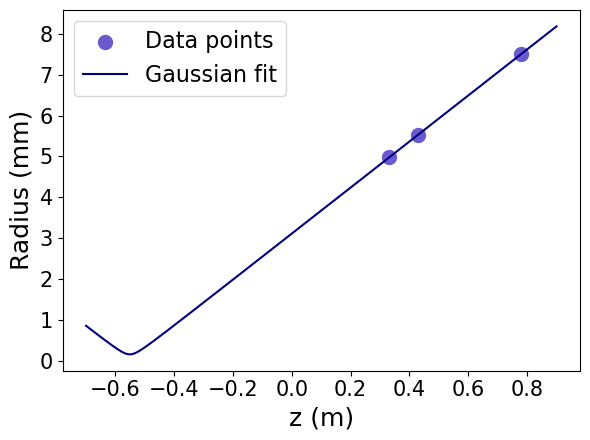

In [17]:
def radius_gaussian(z, w0, z0, wavelength):
    return w0 * np.sqrt(1 + (((z-z0) * wavelength/(np.pi * w0**2))**2))

# fixed wavelength
wavelength = 2700e-9  # example

# your measured radii
radius_data = np.array([
    fit_params[0][2][2] * 1e-3,
    fit_params[1][2][2] * 1e-3,
    fit_params[2][2][2] * 1e-3
])

# corresponding z positions
z_data = np.array([0.33, 0.43, 0.78])

# wrapper so curve_fit only fits w0 and z0
def fit_func(z, w0, z0):
    return radius_gaussian(z, w0, z0, wavelength)

# initial guesses
p0 = [1e-4, -0.2]

# fit
popt, pcov = curve_fit(fit_func, z_data, radius_data, p0=p0)

w0_fit, z0_fit = popt
perr = np.sqrt(np.diag(pcov))
w0_err, z0_err = perr

print(f"w0 = {w0_fit:.4e} ± {w0_err:.4e}")
print(f"z0 = {z0_fit:.4e} ± {z0_err:.4e}")

# smooth curve for plotting
z_plot = np.linspace(min(z_data), max(z_data), 200)
r_plot = fit_func(z_plot, w0_fit, z0_fit)

# plot
plt.figure(figsize=(6,4.5))
for i in range(3):
    plt.scatter(
        z_data[i],
        radius_data[i] * 1000,
        color='slateblue',
        s=100,
        label='Data points' if i == 0 else None
    )
z_values = np.linspace(-0.7, 0.9, 200)
plt.plot(z_values, fit_func(z_values, w0_fit, z0_fit) * 1000, label="Gaussian fit", color = "navy")
plt.xlabel("z (m)", fontsize=18)
plt.ylabel("Radius (mm)", fontsize=18)
plt.xticks(fontsize=15)
plt.yticks(fontsize=15)
plt.legend(fontsize=16)
plt.tight_layout()
plt.savefig("divergence.pdf")
plt.show()

